In [15]:
import torch
import random
import numpy as np
import pandas as pd 
from torch.utils.data import Dataset, DataLoader

In [2]:
HC_adbxd = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/HC_adbxd_30perc.csv', low_memory=False)
HC_adbxd = HC_adbxd.iloc[:, 1:]
HC_adbxd

,1,2,3,4,5,6,7,8,9,10,...,subclass,cell_type,SCBID,MouseID,Age,Strain,Genotype,CFM_14_5_snRNA,14-6-residual,14-6-Bin
0,0.809904,0.658327,-0.020847,-0.982691,-1.121771,-0.148075,1.650261,1.503323,-0.099906,1.528749,...,002 IT EP-CLA Glut,glut,CK19059,2433,14,113,5,49.96,-0.111132,2
1,4.540372,-0.333330,1.210636,0.271568,-1.625993,1.295382,-0.037874,1.378154,0.162137,1.313152,...,002 IT EP-CLA Glut,glut,CK19059,2433,14,113,5,49.96,-0.111132,2
2,-1.613538,0.219264,-1.720945,-0.007177,-0.379468,-1.183066,0.403255,-0.715092,0.733725,0.604334,...,002 IT EP-CLA Glut,glut,CK19059,2433,14,113,5,49.96,-0.111132,2
3,0.078730,1.225353,-0.457267,-0.614239,-0.192410,0.414808,-0.079714,-2.275189,1.646772,1.000489,...,002 IT EP-CLA Glut,glut,CK19059,2433,14,113,5,49.96,-0.111132,2
4,-1.110037,0.613995,0.062297,-0.918579,0.686969,-1.272012,-0.143208,0.748415,-0.003739,-1.545116,...,002 IT EP-CLA Glut,glut,CK19059,2433,14,113,5,49.96,-0.111132,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8491,0.157775,-1.288113,-0.384962,-0.379943,0.645772,-0.009342,-1.236780,-1.811799,-1.466269,0.212603,...,334 Microglia NN,Immune,CK19012,1576,14,D2,5,24.44,-0.673075,1
8492,0.118962,-0.541028,-0.557948,-0.724421,-0.196452,-0.294776,-0.539075,0.508162,-0.726167,-0.775506,...,334 Microglia NN,Immune,CK19012,1576,14,D2,5,24.44,-0.673075,1
8493,-0.063253,-0.131895,1.012909,-1.084712,-0.579701,-0.551220,-0.811287,-0.824723,0.436486,-1.012010,...,334 Microglia NN,Immune,CK19012,1576,14,D2,5,24.44,-0.673075,1
8494,-1.240347,-1.802734,1.181334,1.576435,-0.915664,1.803307,-0.355075,1.807765,-1.725267,0.647679,...,335 BAM NN,Immune,CK19012,1576,14,D2,5,24.44,-0.673075,1


In [3]:
HC_adbxd.iloc[:, 0:4841]

,1,2,3,4,5,6,7,8,9,10,...,4832,4833,4834,4835,4836,4837,4838,4839,4840,4841
0,0.809904,0.658327,-0.020847,-0.982691,-1.121771,-0.148075,1.650261,1.503323,-0.099906,1.528749,...,-0.867632,3.247004,-0.497524,-0.793363,1.508425,-0.594140,0.234379,0.562918,0.770728,-0.118317
1,4.540372,-0.333330,1.210636,0.271568,-1.625993,1.295382,-0.037874,1.378154,0.162137,1.313152,...,-0.423667,0.368246,-0.154014,-1.407807,-0.334520,1.599580,1.249540,1.261240,-1.315822,0.005485
2,-1.613538,0.219264,-1.720945,-0.007177,-0.379468,-1.183066,0.403255,-0.715092,0.733725,0.604334,...,0.191858,-0.242005,-0.647812,-0.095167,-2.672109,-1.256655,-0.068785,-1.008235,-2.417437,2.165459
3,0.078730,1.225353,-0.457267,-0.614239,-0.192410,0.414808,-0.079714,-2.275189,1.646772,1.000489,...,-1.827698,-0.002166,-0.303029,-0.668652,-0.950239,-0.891054,0.301323,-0.547946,-0.363398,0.591803
4,-1.110037,0.613995,0.062297,-0.918579,0.686969,-1.272012,-0.143208,0.748415,-0.003739,-1.545116,...,1.141554,1.225002,0.551906,1.093624,0.976842,-1.520188,-0.519349,-0.700896,1.237232,0.407285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8491,0.157775,-1.288113,-0.384962,-0.379943,0.645772,-0.009342,-1.236780,-1.811799,-1.466269,0.212603,...,-1.494062,0.183227,-0.125226,0.205775,1.070233,-0.314897,1.221884,1.117453,0.510356,-1.799467
8492,0.118962,-0.541028,-0.557948,-0.724421,-0.196452,-0.294776,-0.539075,0.508162,-0.726167,-0.775506,...,0.982297,-1.454332,-1.057100,0.910211,-1.303139,0.608798,1.321323,-0.651639,1.336343,1.261812
8493,-0.063253,-0.131895,1.012909,-1.084712,-0.579701,-0.551220,-0.811287,-0.824723,0.436486,-1.012010,...,0.084263,-0.125721,0.451970,-0.093636,0.973179,0.843554,1.118364,0.536327,0.761890,-0.066495
8494,-1.240347,-1.802734,1.181334,1.576435,-0.915664,1.803307,-0.355075,1.807765,-1.725267,0.647679,...,0.695977,0.830635,-1.193636,0.268940,1.523152,3.828017,2.302212,1.226939,-1.272957,-1.080956


In [4]:
HC_adbxd['14-6-Bin'].unique()

array([2, 3, 0, 1])

In [5]:
HC_adbxd['MouseID'].unique()

array([2433, 1596, 2105, 1490, 1583, 1482, 2644, 1532, 1966, 2648, 5696,
       1576])

In [6]:
PFC_adbxd = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/PFC_adbxd_30perc.csv', low_memory=False)
PFC_adbxd = PFC_adbxd.iloc[:, 1:]

Compare eigenspectrum

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [15]:
zeros = {f'col_{i}': 0 for i in range(8)}
HC_adbxd_sub = HC_adbxd.iloc[:, :4841]
HC_adbxd_sub = HC_adbxd_sub.assign(**zeros)
HC_adbxd_sub

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,...,4810,4811,4812,4813,4814,4815,4816,4817,4818,4819,4820,4821,4822,4823,4824,4825,4826,4827,4828,4829,4830,4831,4832,4833,4834,4835,4836,4837,4838,4839,4840,4841,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7
0,0.809904,0.658327,-0.020847,-0.982691,-1.121771,-0.148075,1.650261,1.503323,-0.099906,1.528749,0.620043,2.544855,-1.545707,0.819592,0.673301,-1.841364,0.992536,1.086405,-0.259100,0.710420,-0.395150,-1.559172,0.559444,-0.424942,-0.816551,-1.849258,-0.460265,-0.583113,0.075662,-2.246707,1.609153,0.268131,-0.008256,-2.058189,-1.982835,-1.624576,-1.146925,-0.764353,0.239721,0.663510,...,0.362873,-0.073011,0.675839,-1.261927,-0.369889,0.413115,-0.172701,-0.225360,-1.287111,-0.234950,0.549519,-3.525283,0.080415,1.834044,1.424523,-0.145060,-1.104022,1.462721,-0.994445,0.405777,0.776598,0.142177,-0.867632,3.247004,-0.497524,-0.793363,1.508425,-0.594140,0.234379,0.562918,0.770728,-0.118317,0,0,0,0,0,0,0,0
1,4.540372,-0.333330,1.210636,0.271568,-1.625993,1.295382,-0.037874,1.378154,0.162137,1.313152,1.073264,-0.678291,-2.348007,0.488708,-2.785244,-0.604915,1.978076,-0.023783,-0.053289,-0.452303,1.990152,0.035600,0.142782,1.213649,0.576438,-0.515397,1.505887,-1.403959,0.657177,-1.435479,-2.705092,2.369446,2.381045,-0.473638,-0.490075,-1.025266,0.908503,1.310754,0.782233,-1.580616,...,2.150081,0.966416,-1.692951,0.839326,0.423964,1.005390,-1.563674,-1.942592,1.269833,-0.430457,1.104756,-0.295030,0.965799,-2.007507,-1.665565,-0.394062,1.798965,0.704187,0.538227,2.245555,0.090227,0.470325,-0.423667,0.368246,-0.154014,-1.407807,-0.334520,1.599580,1.249540,1.261240,-1.315822,0.005485,0,0,0,0,0,0,0,0
2,-1.613538,0.219264,-1.720945,-0.007177,-0.379468,-1.183066,0.403255,-0.715092,0.733725,0.604334,-0.198121,0.546335,-2.307409,0.259257,2.318637,-1.796617,-2.106019,-0.935803,0.106757,-1.023255,-0.115138,-1.265606,-0.222583,-0.097398,-0.385129,-2.900730,-0.349945,-1.960018,-0.475416,-0.827611,-0.960558,2.950747,-1.840263,1.120693,0.490865,-0.592561,-2.695718,3.285058,0.772381,0.465567,...,0.761112,-2.531052,-0.547021,-1.417227,-1.726153,-1.634226,0.394516,0.790909,-1.249127,0.209711,-1.954955,0.833230,1.068881,0.244255,1.004998,-0.691011,-0.036448,-1.106466,0.864323,0.442411,-1.277125,-0.370626,0.191858,-0.242005,-0.647812,-0.095167,-2.672109,-1.256655,-0.068785,-1.008235,-2.417437,2.165459,0,0,0,0,0,0,0,0
3,0.078730,1.225353,-0.457267,-0.614239,-0.192410,0.414808,-0.079714,-2.275189,1.646772,1.000489,0.157568,2.942055,-0.737625,-1.275507,-0.571305,0.566100,-0.939392,1.272607,0.328590,-0.571607,0.629954,-0.235525,0.862352,-1.088930,0.335109,-0.606627,0.591931,0.493759,-0.438833,-0.490836,-0.515265,1.088024,0.639525,0.349986,0.142899,-1.569877,-0.151753,0.435914,0.628066,-0.351569,...,1.005591,1.644000,0.179506,-1.254021,-0.731121,-0.836044,-0.057619,1.010669,-0.075707,-1.873624,-0.271618,-0.612927,0.037453,0.263013,-1.358799,-0.337445,0.651377,-0.503613,1.445887,0.574064,1.702066,-0.624334,-1.827698,-0.002166,-0.303029,-0.668652,-0.950239,-0.891054,0.301323,-0.547946,-0.363398,0.591803,0,0,0,0,0,0,0,0
4,-1.110037,0.613995,0.062297,-0.918579,0.686969,-1.272012,-0.143208,0.748415,-0.003739,-1.545116,0.602048,0.753203,1.058829,0.919808,-0.540037,-2.143255,-0.141187,1.713617,-2.061575,-1.039554,-0.026368,-0.727790,0.772196,-1.031030,-0.249437,-0.978604,-0.787492,0.169041,1.133807,0.440061,-0.927440,-1.541267,0.010695,-1.432859,-0.587621,-0.878645,0.553128,0.591789,0.648428,1.408064,...,0.392043,0.036459,0.089526,-0.666412,0.992349,-0.506355,-0.810424,-0.177058,-1.469742,0.011887,-0.484273,-0.128922,0.704900,-0.967785,0.120844,0.492227,0.268613,0.349028,0.469523,1.073411,0.821757,0.214146,1.141554,1.225002,0.551906,1.093624,0.976842,-1.520188,-0.519349,-0.700896,1.237232,0.407285,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [17]:
joint_hc_pfc_concat = np.concatenate((HC_adbxd_sub, PFC_adbxd.iloc[:, :4849]), axis=0)
joint_hc_pfc_concat

array([[ 0.80990421,  0.65832734, -0.02084726, ...,  0.        ,
         0.        ,  0.        ],
       [ 4.54037234, -0.33332993,  1.21063556, ...,  0.        ,
         0.        ,  0.        ],
       [-1.61353832,  0.21926426, -1.72094479, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.24848989,  0.97129622,  1.43738741, ...,  0.34707864,
        -0.61781229, -0.55926191],
       [ 0.31627201,  0.68052278,  0.32554313, ...,  0.27099621,
         0.55274037,  0.40330753],
       [-1.2470999 , -1.30349003,  0.5581172 , ..., -0.9847877 ,
         1.6696158 , -0.75330123]])

<Figure size 1000x600 with 0 Axes>

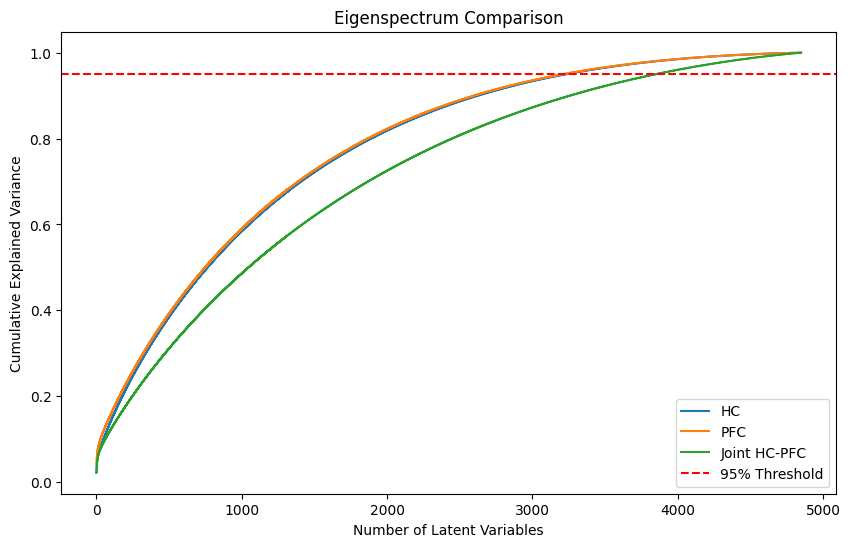

In [18]:
pca_hc = PCA().fit(HC_adbxd_sub.values)
pca_pfc = PCA().fit(PFC_adbxd.iloc[:, :4849].values)
pca_joint = PCA().fit(joint_hc_pfc_concat)

cum_var1 = np.cumsum(pca_hc.explained_variance_ratio_)
cum_var2 = np.cumsum(pca_pfc.explained_variance_ratio_)
cum_var_joint = np.cumsum(pca_joint.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
plt.step(range(1, len(cum_var1)+1), cum_var1, where='mid', label='HC')
plt.step(range(1, len(cum_var2)+1), cum_var2, where='mid', label='PFC')
plt.step(range(1, len(cum_var_joint)+1), cum_var_joint, where='mid', label='Joint HC-PFC')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.xlabel('Number of Latent Variables')
plt.ylabel('Cumulative Explained Variance')
plt.title('Eigenspectrum Comparison')
plt.legend()
plt.show()

In [15]:
PFC_subclass = PFC_adbxd['subclass'].unique()
len(PFC_subclass)

77

In [16]:
HC_subclass = HC_adbxd['subclass'].unique()
HC_subclass

array(['002 IT EP-CLA Glut', '003 L5/6 IT TPE-ENT Glut',
       '006 L4/5 IT CTX Glut', '007 L2/3 IT CTX Glut',
       '008 L2/3 IT ENT Glut', '009 L2/3 IT PIR-ENTl Glut',
       '011 L2 IT ENT-po Glut', '014 LA-BLA-BMA-PA Glut',
       '015 ENTmv-PA-COAp Glut', '016 CA1-ProS Glut', '017 CA3 Glut',
       '018 L2 IT PPP-APr Glut', '019 L2/3 IT PPP Glut',
       '022 L5 ET CTX Glut', '023 SUB-ProS Glut', '024 L5 PPP Glut',
       '028 L6b/CT ENT Glut', '030 L6 CT CTX Glut', '031 CT SUB Glut',
       '033 NP SUB Glut', '034 NP PPP Glut', '036 HPF CR Glut',
       '037 DG Glut', '046 Vip Gaba', '047 Sncg Gaba',
       '048 RHP-COA Ndnf Gaba', '049 Lamp5 Gaba', '050 Lamp5 Lhx6 Gaba',
       '051 Pvalb chandelier Gaba', '052 Pvalb Gaba', '053 Sst Gaba',
       '056 Sst Chodl Gaba', '319 Astro-TE NN', '327 Oligo NN',
       '334 Microglia NN', '001 CLA-EPd-CTX Car3 Glut',
       '004 L6 IT CTX Glut', '020 L2/3 IT RSP Glut', '025 CA2-FC-IG Glut',
       '032 L5 NP CTX Glut', '335 BAM NN'], dt

In [17]:
len(HC_subclass)

41

In [18]:
len(PFC_adbxd['Strain'].unique())

13

In [19]:
HC_adbxd['Strain'].unique()

array(['113', '124', '161', '28', '33', '39', '50', '65', '83', '99',
       'B6', 'D2'], dtype=object)

In [20]:
HC_adbxd['Strain'].value_counts()

Strain
33     1509
39     1156
124    1110
D2      964
113     792
161     750
50      635
65      403
83      356
B6      355
99      236
28      230
Name: count, dtype: int64

In [21]:
PFC_adbxd['Strain'].value_counts()

Strain
124    1067
113     979
D2      963
33      916
83      818
39      723
65      589
99      543
161     531
53      524
28      343
50      341
B6      302
Name: count, dtype: int64

In [7]:
def create_joint_df(dataset1, dataset2, dataset_abbrev_1, dataset_abbrev_2, join_col='Strain'):
    all_pairs = []

    strains1 = set(dataset1[join_col].unique())
    strains2 = set(dataset2[join_col].unique())
    common_strains = strains1.intersection(strains2)

    num_strain_diff = {}
    for strain in common_strains:
        idx1 = dataset1[dataset1[join_col] == strain].index.tolist()
        idx2 = dataset2[dataset2[join_col] == strain].index.tolist()
        max_count = max(len(idx1), len(idx2))

        #print(strain)
        num_strain_diff[str(strain)] = (len(idx1) - len(idx2))

        samples1 = random.choices(idx1, k=max_count)
        samples2 = random.choices(idx2, k=max_count)

        all_pairs.extend(list(zip(samples1, samples2)))

    rows1 = dataset1.loc[[p[0] for p in all_pairs]].reset_index(drop=True).add_suffix(f'_{dataset_abbrev_1}')
    rows2 = dataset2.loc[[p[1] for p in all_pairs]].reset_index(drop=True).add_suffix(f'_{dataset_abbrev_2}')

    paired_df = pd.concat([rows1, rows2], axis=1)

    paired_df['strain'] = paired_df[f'{join_col}_{dataset_abbrev_2}']
    paired_df = paired_df.drop(columns=[f'{join_col}_{dataset_abbrev_2}', f'{join_col}_{dataset_abbrev_1}'])
    num_strain_diff_df = pd.DataFrame(list(num_strain_diff.items()), columns=['Strain', 'numHC_minus_numPFC'])

    return paired_df, num_strain_diff_df

In [8]:
paired_df, num_strain_diff_df = create_joint_df(HC_adbxd, PFC_adbxd, 'HC', 'PFC', join_col='Strain')

In [16]:
# calculate original variance of the hc and pfc data 
hc_orig_variance = np.var(paired_df.iloc[:, :4841], axis=0).mean().item()
pfc_orig_variance = np.var(paired_df.iloc[:, 4851:4851+4849], axis=0).mean().item()
hc_orig_variance, pfc_orig_variance

(1.0023949173215865, 1.0148728502102304)

In [49]:
sameregion_paired_df.iloc[:, :4841]

,1_HC1,2_HC1,3_HC1,4_HC1,5_HC1,6_HC1,7_HC1,8_HC1,9_HC1,10_HC1,...,4832_HC1,4833_HC1,4834_HC1,4835_HC1,4836_HC1,4837_HC1,4838_HC1,4839_HC1,4840_HC1,4841_HC1
0,-1.609628,0.009209,0.839971,0.070498,-0.099665,-0.097126,-0.066542,-0.407981,-2.009269,0.196589,...,-0.161226,0.643744,0.171869,0.641311,-0.475897,1.057837,-0.829293,0.070499,-0.802527,1.273241
1,0.198664,-0.566786,-1.035253,0.842681,0.011201,0.105975,0.404302,-0.423952,0.245089,-0.733742,...,-0.468563,-0.762174,0.356000,0.597520,0.333413,-1.079328,0.234750,0.135718,-0.357615,-1.062258
2,-1.330949,0.637473,0.204972,-0.364560,-0.030480,0.153343,-0.695475,0.638559,-1.108201,0.019278,...,0.204718,-0.884746,1.337536,-0.019986,-1.210678,1.813860,0.357249,-0.389114,-0.697643,-0.332174
3,-0.631584,1.390899,-2.092378,1.739342,-0.803180,-0.510201,0.004095,1.055494,1.733506,1.700430,...,-1.462642,0.713478,-1.342775,1.676104,1.529094,-1.331704,-0.290830,-1.861237,2.188449,-0.465362
4,-0.399974,0.261885,-0.225965,-1.085756,0.046474,0.026377,-0.398146,-0.184325,0.139291,-0.123096,...,0.340685,0.314035,1.015370,0.757339,-0.879514,1.127948,0.891791,-0.116203,1.637921,0.635536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8491,0.153431,0.170681,0.869901,-3.190511,0.912943,1.353368,1.082189,0.346161,0.904052,0.023554,...,1.024511,0.152488,0.557750,1.419883,1.320249,0.285246,0.143037,-0.925982,1.116633,-1.920741
8492,0.086061,-2.786307,-4.193004,-1.063957,-0.406136,-3.110647,1.600962,1.708851,-1.069227,-0.591217,...,-1.683586,0.045141,-2.224842,-0.163048,0.191112,0.431723,1.349840,-0.646342,0.876875,1.775852
8493,-0.079144,1.466729,0.076948,0.376957,-2.763893,-1.371299,-0.955034,0.251989,1.726911,1.406702,...,2.326855,1.421262,2.512070,-2.649088,0.727895,-2.795066,-0.893825,-0.137598,-0.002177,0.827825
8494,0.750030,0.101816,0.034043,3.578889,-2.306464,0.908432,-0.130002,-0.221022,0.193977,0.294175,...,-0.418894,0.178112,-0.974872,-2.808913,-0.678245,0.475083,0.280615,0.669919,1.411160,2.169158


In [57]:
sameregion_paired_df.iloc[:, 4851:4851+4841]

,1_HC2,2_HC2,3_HC2,4_HC2,5_HC2,6_HC2,7_HC2,8_HC2,9_HC2,10_HC2,...,4832_HC2,4833_HC2,4834_HC2,4835_HC2,4836_HC2,4837_HC2,4838_HC2,4839_HC2,4840_HC2,4841_HC2
0,-0.778044,-1.119398,-0.770185,1.593890,-0.394309,1.420356,-0.260943,-0.066538,-0.781137,-1.188386,...,1.420337,-2.622494,-0.487459,-1.964183,-0.274696,1.806722,0.677607,-1.734981,0.969757,0.670547
1,-0.364457,0.823339,0.274823,-0.054027,-0.580271,0.251335,-0.595737,-0.524601,-0.888792,2.177524,...,0.755777,1.450106,-0.103187,1.244335,0.779216,-1.682384,0.514984,0.239489,-0.197177,-1.116545
2,0.160113,-0.071303,-0.003432,0.700359,0.885168,0.053275,0.546520,-0.321983,-0.861070,-0.100716,...,-0.186197,0.648883,-0.201894,-0.991971,-1.309903,-0.409838,1.702460,-0.012611,0.420918,0.727613
3,0.679488,-0.254456,0.664608,-1.944588,0.942043,2.753730,0.434518,-0.516271,-1.081608,-1.618418,...,1.062833,0.042149,-0.138073,-1.186558,-0.465686,-0.241675,1.841502,-0.691822,-2.611432,0.599072
4,-0.203399,-0.454993,-0.224547,-0.297638,0.359860,0.250269,0.596859,1.453694,0.391638,-0.449089,...,0.566193,-0.375917,-1.704029,0.066870,-0.351144,-1.075462,0.553008,0.082079,0.185176,-0.621758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8491,-1.658037,-0.191841,1.463876,-2.241706,1.656830,-0.835398,0.377292,2.403390,1.222729,-0.332206,...,-0.214952,0.972652,0.234879,-1.379757,-0.498841,-0.227239,-0.848104,-0.261219,1.101342,0.840556
8492,0.964529,-1.364419,1.310601,-1.176579,0.962754,-2.007017,-1.537480,-1.571201,-1.270887,0.123974,...,-0.209162,-0.434286,-0.732840,1.047383,-0.369974,0.007442,-0.619974,-1.139588,0.093967,-0.324521
8493,0.084197,0.398184,0.153835,0.803394,-1.006534,-1.613176,1.735423,-0.152639,0.104999,-0.492993,...,-0.198396,0.436737,1.247353,2.757675,-2.124020,-0.348183,-2.387706,1.740421,-2.122779,-0.573039
8494,-0.703950,-0.273338,-1.441001,0.769413,0.012217,-0.779130,0.044025,0.360262,0.961488,-0.736506,...,0.420606,2.075200,-0.973691,-0.554498,-0.663277,0.770631,1.157327,1.046262,-0.010035,-0.472793


In [33]:
sameregion_paired_df, _ = create_joint_df(HC_adbxd, HC_adbxd, 'HC1', 'HC2', join_col='Strain')

In [23]:
sameregion_paired_df.iloc[:, :4842]

,1_HC1,2_HC1,3_HC1,4_HC1,5_HC1,6_HC1,7_HC1,8_HC1,9_HC1,10_HC1,...,4833_HC1,4834_HC1,4835_HC1,4836_HC1,4837_HC1,4838_HC1,4839_HC1,4840_HC1,4841_HC1,barcode_HC1
0,0.650550,1.121291,0.720114,-1.155365,-1.118835,-0.551951,-0.156711,-1.397148,-0.913671,0.847726,...,-0.041381,0.371632,-1.501549,-0.726312,-2.630326,0.958856,-0.046276,-0.995437,0.367925,CK19012_TTACTGTCACTCCACT-1
1,-1.322411,0.251483,-0.372920,-0.618174,-2.717376,-0.526443,0.594400,-2.107257,-0.229636,0.600115,...,-1.075824,-1.207524,0.079115,-0.169552,0.333513,0.130459,1.465832,-0.108829,0.904103,CK19012_GAAGAATTCGGTAGGA-1
2,0.752308,0.898855,-0.080308,0.964233,-0.783097,1.354831,1.377096,-1.928753,0.414010,0.708687,...,-0.053092,0.670512,-0.054369,0.630455,-0.435258,-0.107399,-0.390703,-0.177268,-0.122927,CK19012_CCACGTTGTTCCATTT-1
3,-1.029186,0.882760,0.293896,0.142997,-0.226817,0.230316,0.225161,-1.258561,-0.080314,0.792346,...,-0.262393,-0.080783,0.237785,-0.806273,-0.425242,-0.120620,0.690881,-0.275247,-0.105013,CK19012_TCCTCTTGTGAGAACC-1
4,-0.645600,0.029531,-0.395399,-0.349062,-0.745433,-0.681647,-0.446784,-0.081369,-0.590848,-1.088658,...,0.074970,0.572233,0.007810,0.062143,0.010885,1.002777,0.051800,-0.722856,-0.829144,CK19012_GTGTGATGTCCAGCCA-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8491,1.171121,-0.286728,0.411715,1.171867,-0.992839,0.852296,0.106413,1.183424,0.574362,0.884444,...,1.529404,2.070873,-1.313090,1.186147,1.736237,0.059133,-1.153565,-0.038498,1.527669,CK19093_CCGTGAGCATCCTAAG-1
8492,1.536397,0.068367,-0.174697,-0.467613,-1.276612,-1.079921,-1.032482,-0.140545,0.987106,0.120662,...,-0.804437,0.975224,1.143274,0.731319,0.816308,0.098147,1.996279,-1.185835,1.841240,CK19093_TCTGGCTTCAATCAGC-1
8493,0.376294,-1.623881,-0.023208,0.102589,0.619268,-2.290003,0.703342,-0.207152,-0.067541,1.954740,...,-0.431470,0.759727,-1.294498,-2.661433,-0.890668,2.463438,-0.106032,-0.920061,1.830036,CK19093_TGTTACTAGGTTCTAC-1
8494,-1.936226,-1.149019,1.063068,-0.304645,-1.718794,-0.504106,0.859089,-0.381370,0.189788,-1.683138,...,-4.157534,-0.695818,-3.037972,3.638003,0.262197,-0.644417,-1.519064,0.512687,-0.358316,CK19093_CCTCAGTCACAATGTC-1


In [25]:
sameregion_paired_df['0_HC1']

KeyError: '0_HC1'

In [18]:
sameregion_paired_df.iloc[:, 4850:4851+4842]

,14-6-Bin_HC1,1_HC2,2_HC2,3_HC2,4_HC2,5_HC2,6_HC2,7_HC2,8_HC2,9_HC2,...,4833_HC2,4834_HC2,4835_HC2,4836_HC2,4837_HC2,4838_HC2,4839_HC2,4840_HC2,4841_HC2,barcode_HC2
0,1,-1.344477,-0.015525,-0.368049,-0.696536,-0.187865,-0.498506,-0.183919,-0.623152,0.797044,...,2.349051,-0.258641,-0.351521,0.121043,0.008961,0.612016,0.360808,-1.464802,-0.779833,CK19012_ACCTACCCAGGTGTTT-1
1,1,-0.003842,-0.136171,0.325976,0.424712,-0.796675,-0.638086,-0.397997,1.138677,-0.578508,...,-0.143803,1.926939,-0.148056,-1.552281,-0.559065,-0.290897,-0.318833,-0.896185,-1.274174,CK19012_TGGGATTGTCCTTAAG-1
2,1,-0.757995,0.375777,-0.891968,0.051117,0.237530,-0.543144,0.859536,0.200725,-0.745630,...,-0.017331,0.681066,-0.274998,0.386238,0.551557,-1.645440,-1.174007,-1.117775,0.755552,CK19012_ATCTCTAAGAAGTCCG-1
3,1,0.002523,0.642443,-1.433964,0.670647,2.073197,-0.676976,0.789171,-0.532007,-0.002964,...,-0.998733,-0.012671,-0.949478,-0.530346,0.734427,0.001930,-0.144694,-0.629794,1.245786,CK19012_ACCGTTCAGAGCTGAC-1
4,1,0.846244,1.513690,-1.018985,-0.601971,0.035908,0.051327,-0.039164,-0.600406,-0.079452,...,0.526579,-0.468391,-0.167722,0.527580,0.272930,1.530619,0.469724,-0.699688,0.588486,CK19012_CTCCTTTAGAAATGGG-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8491,1,1.379280,-0.269835,0.351939,-0.604678,0.550248,-0.891182,-0.046617,0.747554,-0.073162,...,0.048753,-1.108720,-0.966568,-1.775723,-0.793959,-3.020320,-0.501875,-0.571177,-0.872068,CK19093_TATTTCGAGCATCCCG-1
8492,1,-0.719157,0.155271,0.948642,-2.838323,-0.892779,-1.519800,1.228910,0.123480,1.208492,...,-1.134138,0.487589,0.138410,-1.513507,0.095558,-2.091060,0.769888,-0.656324,3.142158,CK19093_TACGGGCAGTCATGGG-1
8493,1,-0.952024,0.792208,0.094389,2.632507,-1.873176,0.380587,-3.843666,0.418903,0.134437,...,0.258192,-1.528736,0.376254,-0.391650,0.501292,-0.450884,-0.052261,-0.894958,-1.179838,CK19093_GGAATGGCAGGATCTT-1
8494,1,-1.486109,-1.049041,1.949626,-1.825660,1.796555,0.560397,-0.536325,0.097928,-2.464714,...,0.410580,0.629462,-0.792986,-3.013193,-0.598293,0.936835,2.277795,2.712527,0.371014,CK19093_CTTGATTTCATTTGTC-1


In [10]:
sameregion_paired_df.to_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/sameregionhc_paired.csv', index=False)

In [ ]:
#num_strain_diff_df.to_csv('/home/riritani/mm-vae/num_strain_diff.csv', index=False)

In [1]:
paired_df.iloc[:, 4844:]

NameError: name 'paired_df' is not defined

In [1]:
paired_df

NameError: name 'paired_df' is not defined

In [ ]:
#paired_df.to_csv('/home/riritani/mm-vae/hc_pfc_adbxd_paired_30perc.csv', index=False)

In [ ]:
# download sample data to test data loading
# paired_df[:20].to_csv('/home/riritani/mm-vae/sampletest_hc_pfc_adbxd_paired.csv', index=False)

In [ ]:
paired_df[['14-6-Bin_HC', '14-6-Bin_PFC']][10000:32000]

In [ ]:
# PFC dataset is 0:4851, HC dataset is 4852:

In [ ]:
# will add to main after testing 
hc_cols = [col for col in paired_df.columns if col.endswith('HC')]
hc_meta_cols = ['barcode_HC', 'subclass_HC', 'cell_type_HC', 'SCBID_HC', 'MouseID_HC', 'Age_HC', 'Genotype_HC', 'CFM_14_5_snRNA_HC', '14-6-residual_HC', '14-6-Bin_HC', 'strain']
hc_data_cols = [col for col in hc_cols if col not in hc_meta_cols]
pfc_cols = [col for col in paired_df.columns if col.endswith('PFC')]
pfc_meta_cols = ['barcode_PFC', 'subclass_PFC', 'cell_type_PFC', 'SCBID_PFC', 'MouseID_PFC', 'Age_PFC', 'Genotype_PFC', 'CFM_14_5_snRNA_PFC', '14-6-residual_PFC', '14-6-Bin_PFC', 'strain']
pfc_data_cols = [col for col in pfc_cols if col not in pfc_meta_cols]

In [ ]:
class PairedRegionDataset(Dataset):
    def __init__(self, paired_df, data_cols_hc, data_cols_pfc, meta_cols_hc, meta_cols_pfc, label_col, join_col='Strain'): 
        self.paired_df = paired_df
        self.join_col = join_col
        self.label_col = label_col

        self.data_cols_hc = data_cols_hc
        self.data_cols_pfc = data_cols_pfc
        self.meta_cols_hc = meta_cols_hc
        self.meta_cols_pfc = meta_cols_pfc

    def __len__(self):
        return len(self.paired_df)

    def __getitem__(self, idx):
        sample = self.paired_df.iloc[idx]

        # for HC 
        data_hc = torch.tensor(sample[self.data_cols_hc].values.astype('float32'))
        label_hc = sample[self.label_col]
        meta_hc = sample[self.meta_cols_hc].to_dict()

        # for PFC 
        data_pfc = torch.tensor(sample[self.data_cols_pfc].values.astype('float32'))
        label_pfc = sample[self.label_col]
        meta_pfc = sample[self.meta_cols_pfc].to_dict()

        return (data_hc, label_hc, meta_hc), (data_pfc, label_pfc, meta_pfc)

In [ ]:
dataset = PairedRegionDataset(paired_df, hc_data_cols, pfc_data_cols, hc_meta_cols, pfc_meta_cols, '14-6-Bin_HC', 'Strain')

In [ ]:
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

In [ ]:
first_iter = next(iter(dataloader))

In [ ]:
first_iter[0][0].shape

In [ ]:
first_iter[1][0].shape

In [ ]:
first_iter[0][1].shape

In [ ]:
first_iter[1][1].shape

In [ ]:
len(first_iter[0][2])

In [ ]:
len(first_iter[1][2])

In [9]:
full = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv')
full

/tmp/ipykernel_2470050/1589472739.py:1: DtypeWarning: Columns (9712) have mixed types. Specify dtype option on import or set low_memory=False.
  full = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv')


,0_HC,1_HC,2_HC,3_HC,4_HC,5_HC,6_HC,7_HC,8_HC,9_HC,...,subclass_PFC,cell_type_PFC,SCBID_PFC,MouseID_PFC,Age_PFC,Genotype_PFC,CFM_14_5_snRNA_PFC,14-6-residual_PFC,14-6-Bin_PFC,strain
0,1.032911,0.930804,-0.506429,0.399180,-1.665557,-0.169929,-0.412642,-1.081330,-0.263578,-1.602702,...,334 Microglia NN,Immune,CK19032,1596,14,5,59.16,0.738297,3,124
1,0.652837,0.454148,0.879128,0.030314,-1.489111,0.785163,0.211441,0.474034,-0.107822,-0.063107,...,319 Astro-TE NN,Astrocytes,CK19032,1596,14,5,59.16,0.738297,3,124
2,-0.467760,0.498727,0.423371,-0.196953,-0.577146,-0.254714,0.647625,0.110877,-0.037445,-0.114378,...,030 L6 CT CTX Glut,Glut,CK19032,1596,14,5,59.16,0.738297,3,124
3,0.269693,0.008788,0.001615,0.248190,0.531861,0.174182,-0.656014,0.324071,-0.270391,-0.172469,...,007 L2/3 IT CTX Glut,Glut,CK19032,1596,14,5,59.16,0.738297,3,124
4,0.474351,2.694790,-2.235378,1.500846,-0.067623,0.446731,0.536872,0.355713,-0.701760,-0.677066,...,327 Oligo NN,Oligo,CK19032,1596,14,5,59.16,0.738297,3,124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-0.749929,-0.952024,0.792208,0.094389,2.632507,-1.873176,0.380587,-3.843666,0.418903,0.134437,...,334 Microglia NN,Immune,CK19090,1490,14,5,39.47,-0.460462,1,28
9747,-0.521517,-1.567496,0.704327,-0.186926,1.173094,-0.662684,-0.474026,0.286059,1.187299,1.694772,...,066 NDB-SI-ant Prdm12 Gaba,Gaba,CK19090,1490,14,5,39.47,-0.460462,1,28
9748,0.030754,-1.881689,-0.582833,2.284414,0.035602,1.502603,1.283200,0.003121,1.818799,0.914294,...,327 Oligo NN,Oligo,CK19090,1490,14,5,39.47,-0.460462,1,28
9749,-0.178791,-0.578603,0.148001,-0.718415,-0.050875,0.533299,1.350025,-1.728900,-1.629589,0.284877,...,010 IT AON-TT-DP Glut,Glut,CK19090,1490,14,5,39.47,-0.460462,1,28


In [8]:
new_residuals = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/HPC_strain_QRT_Bin.csv')
new_residuals

,Strain,CFM_14_5_snRNA,14-6-residual,14-6-Bin
0,83,29.38,-0.989843,0
1,161,20.58,-0.974140,0
2,65,52.09,-0.928484,0
3,50,28.04,-0.627820,1
4,D2,24.44,-0.552464,1
5,28,39.47,-0.460462,1
6,39,41.56,-0.234839,2
7,113,49.96,-0.148236,2
8,33,56.67,0.133901,2
9,B6,31.38,0.583512,3


In [10]:
mapping_residual = new_residuals.set_index('Strain')['14-6-residual']
mapping_snRNA = new_residuals.set_index('Strain')['CFM_14_5_snRNA']

In [17]:
type(new_residuals['Strain'][0])

str

In [29]:
full_new['strain'].unique()

array(['124', '83', '50', '39', 'B6', '65', 'D2', '33', '113', '99',
       '161', '28'], dtype=object)

In [26]:
full_new = full.copy()
full_new['strain'] = full_new['strain'].astype(str)
full_new['14-6-residual_PFC'] = full_new['strain'].map(mapping_residual)
full_new['14-6-residual_HC'] = full_new['strain'].map(mapping_residual)

In [30]:
full_new['CFM_14_5_snRNA_PFC'] = full_new['strain'].map(mapping_snRNA)
full_new['CFM_14_5_snRNA_HC'] = full_new['strain'].map(mapping_snRNA)

In [10]:
#ull.iloc[:20, :].to_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/sampletest_hc_pfc_adbxd_paired.csv', index=False)

In [32]:
full_new.to_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc_FIXED.csv')

Verify normalization

In [2]:
import matplotlib.pyplot as plt

In [3]:
norm = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv')

/tmp/ipykernel_14859/940678472.py:1: DtypeWarning: Columns (9712) have mixed types. Specify dtype option on import or set low_memory=False.
  norm = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv')


In [7]:
norm.iloc[:, :4842]

,0_HC,1_HC,2_HC,3_HC,4_HC,5_HC,6_HC,7_HC,8_HC,9_HC,...,4832_HC,4833_HC,4834_HC,4835_HC,4836_HC,4837_HC,4838_HC,4839_HC,4840_HC,4841_HC
0,1.032911,0.930804,-0.506429,0.399180,-1.665557,-0.169929,-0.412642,-1.081330,-0.263578,-1.602702,...,1.232984,-0.207667,0.272939,0.258212,0.372748,-0.380447,0.780489,0.322647,0.756226,0.082748
1,0.652837,0.454148,0.879128,0.030314,-1.489111,0.785163,0.211441,0.474034,-0.107822,-0.063107,...,0.038191,0.461753,-0.540708,2.044811,0.342706,-0.242654,0.062811,0.926350,0.180652,-0.026177
2,-0.467760,0.498727,0.423371,-0.196953,-0.577146,-0.254714,0.647625,0.110877,-0.037445,-0.114378,...,0.605839,0.201803,0.326389,-1.329903,0.886893,-0.268153,-0.433313,-1.402327,-0.802870,0.654489
3,0.269693,0.008788,0.001615,0.248190,0.531861,0.174182,-0.656014,0.324071,-0.270391,-0.172469,...,0.688423,1.084811,-1.153715,-0.033964,0.067661,-0.140669,0.744527,0.257878,0.573208,-0.442422
4,0.474351,2.694790,-2.235378,1.500846,-0.067623,0.446731,0.536872,0.355713,-0.701760,-0.677066,...,-0.581120,-0.572206,-1.747488,-2.174942,1.304734,0.233140,1.001018,-1.516556,0.025188,-0.718396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-0.749929,-0.952024,0.792208,0.094389,2.632507,-1.873176,0.380587,-3.843666,0.418903,0.134437,...,-0.762877,0.258192,-1.528736,0.376254,-0.391650,0.501292,-0.450884,-0.052261,-0.894958,-1.179838
9747,-0.521517,-1.567496,0.704327,-0.186926,1.173094,-0.662684,-0.474026,0.286059,1.187299,1.694772,...,-1.586572,0.545810,-1.435995,0.563981,1.142765,-0.286438,0.518607,-0.308677,0.634129,-0.916145
9748,0.030754,-1.881689,-0.582833,2.284414,0.035602,1.502603,1.283200,0.003121,1.818799,0.914294,...,2.209747,-0.661178,0.744737,0.416583,-2.443281,0.111844,0.640662,-0.130795,1.181687,1.777419
9749,-0.178791,-0.578603,0.148001,-0.718415,-0.050875,0.533299,1.350025,-1.728900,-1.629589,0.284877,...,0.375211,2.140555,-2.619549,1.062907,-1.654221,-0.772506,0.998086,0.783051,0.113586,1.208630


In [14]:
norm.iloc[:, :4842].values

array([[ 1.03291066,  0.93080439, -0.50642928, ...,  0.32264685,
         0.75622622,  0.08274846],
       [ 0.652837  ,  0.45414827,  0.87912783, ...,  0.92634994,
         0.18065204, -0.02617661],
       [-0.46775999,  0.49872712,  0.4233711 , ..., -1.40232693,
        -0.80286979,  0.65448919],
       ...,
       [ 0.03075446, -1.88168875, -0.58283348, ..., -0.13079486,
         1.18168671,  1.77741922],
       [-0.17879087, -0.57860295,  0.14800123, ...,  0.783051  ,
         0.113586  ,  1.20863003],
       [-1.51956587,  2.86164894, -0.00424831, ..., -0.68497637,
         1.43215286, -0.9691364 ]])

Text(0.5, 1.0, 'Distribution of normalized HC data')

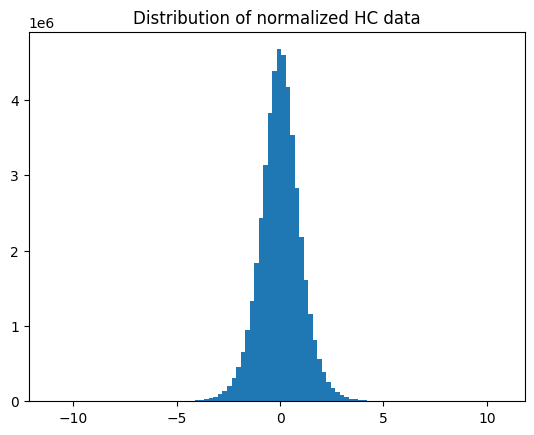

In [5]:
plt.hist(norm.iloc[:, :4842].values.flatten(), bins=100)
plt.title('Distribution of normalized HC data')

In [25]:
norm.iloc[:, 4842+10:-11]

,0_PFC,1_PFC,2_PFC,3_PFC,4_PFC,5_PFC,6_PFC,7_PFC,8_PFC,9_PFC,...,4840_PFC,4841_PFC,4842_PFC,4843_PFC,4844_PFC,4845_PFC,4846_PFC,4847_PFC,4848_PFC,4849_PFC
0,-0.200120,0.705366,-0.295936,-0.319175,-0.135122,-0.710021,-0.234006,1.181633,-0.382194,1.087855,...,-0.514852,1.093156,-0.329371,-2.335438,-0.120136,-0.078509,-0.811967,0.384397,-0.599988,0.847673
1,-1.213398,1.457755,-1.618366,-0.403789,0.233500,-1.146830,0.645196,0.105234,-1.693521,-0.139205,...,0.025570,0.301849,-0.180008,-1.459600,0.050232,-0.164041,-1.906638,1.025126,-0.274191,-0.496676
2,1.379070,-0.643238,1.714716,0.122016,0.858598,0.345244,-0.792924,0.217080,-0.673692,0.298618,...,0.892500,-0.552276,1.420493,-1.009985,0.126458,-0.181512,0.450062,-0.580798,-0.401776,-0.521655
3,0.265045,0.840968,1.546958,-0.647346,-0.288133,-0.324822,-0.021153,0.977456,-1.888465,-1.529452,...,-0.648032,1.589933,2.972394,0.037811,0.833486,0.285679,1.391296,1.574510,1.232619,0.969969
4,0.050263,0.527289,-0.615692,-0.570277,-0.066994,-0.301883,0.442068,0.281561,0.272677,-0.073763,...,0.415426,0.613094,0.381548,0.092024,-0.135387,-0.782313,-1.163319,-0.262801,-0.939735,0.043327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-0.217084,0.043876,-0.788866,0.928843,0.533087,-0.649767,0.187654,0.030390,-0.566349,1.373548,...,-0.137547,0.898547,0.640106,-0.539893,0.051508,0.332709,-0.062760,0.292250,0.759995,-0.352486
9747,1.092337,0.208914,-1.387216,0.084945,0.048084,0.360754,-0.159911,-0.414608,1.525564,-0.873947,...,0.220460,1.247422,0.781837,0.021049,1.985850,-1.232624,1.154993,0.058199,-0.813539,-0.191037
9748,0.518112,1.330562,1.334708,0.620196,0.373301,-0.742282,0.515891,0.038578,-0.751587,0.979666,...,0.421122,-0.592161,0.464232,-1.136950,0.367430,0.180088,-0.188049,0.072719,0.179569,0.658156
9749,0.430178,-0.113759,0.594333,0.235588,-1.257731,-0.533649,-1.327627,1.113942,-1.331212,0.479821,...,0.632337,0.204687,0.245517,-0.047682,-1.199170,0.248172,0.517354,-1.718730,0.246154,-0.778357


Text(0.5, 1.0, 'Distribution of normalized PFC data')

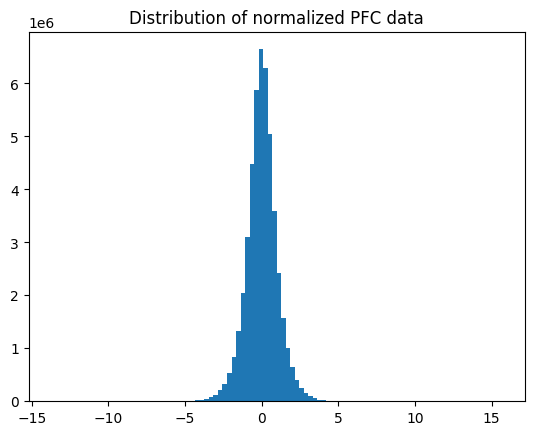

In [6]:
plt.hist(norm.iloc[:, 4842+10:-11].values.flatten(), bins=100)
plt.title('Distribution of normalized PFC data')

(array([ 750., 1599., 1173.,    0.,  343., 1156.,    0.,  979., 1132.,
        2619.]),
 array([20.58 , 24.438, 28.296, 32.154, 36.012, 39.87 , 43.728, 47.586,
        51.444, 55.302, 59.16 ]),
 <BarContainer object of 10 artists>)

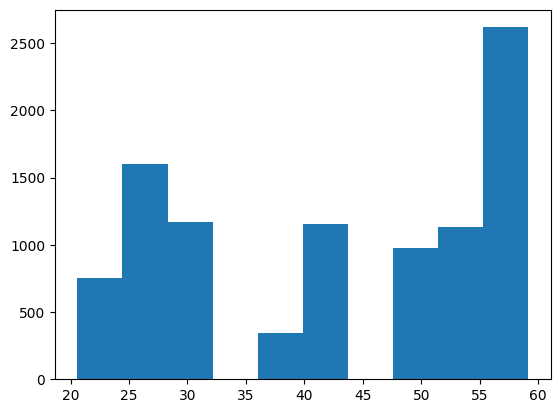

In [8]:
plt.hist(norm['CFM_14_5_snRNA_PFC'])